# Analysis of Variance (ANOVA)

This notebook demonstrates:

- ANOVA fundamentals
- Factors and levels
- ANOVA assumptions
- Types of ANOVA
- Hypothesis testing
- Sum of Squares
- Degrees of Freedom
- Mean Squares
- F-statistic
- Critical value
- One-Way ANOVA using Python

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# 1. Factors and Levels

A **factor** is the variable being studied.

A **level** is a value or category within that factor.

Example:

**Factor:** Medicine

**Levels:**

- 5 mg
- 10 mg
- 15 mg

In [2]:
medicine = "Medicine"
levels = ["5 mg", "10 mg", "15 mg"]

print("Factor:", medicine)
print("Levels:", levels)

Factor: Medicine
Levels: ['5 mg', '10 mg', '15 mg']


# 2. ANOVA Assumptions

The four assumptions discussed are:

1. Normality
2. Absence of problematic outliers
3. Homogeneity of variance
4. Independent and randomly selected samples

Memory trick:

$$
\boxed{\text{N-O-H-I}}
$$

## N — Normality

The sampling distribution of the mean should be approximately normally
distributed.

This connects to the Central Limit Theorem.

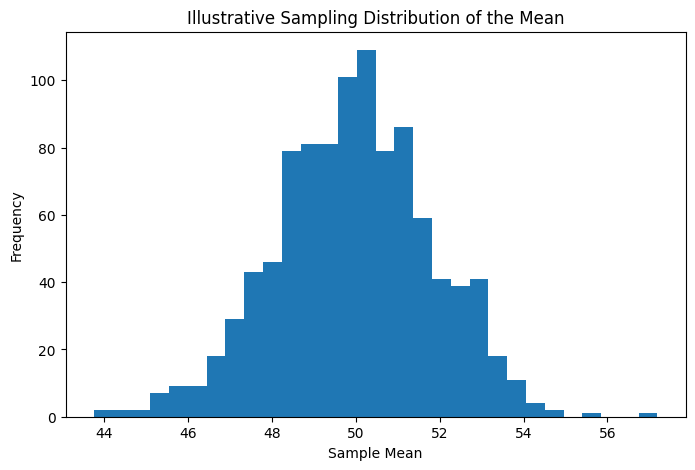

In [3]:
# Illustrative sampling distribution of means

rng = np.random.default_rng(42)

population = rng.normal(loc=50, scale=10, size=10000)

sample_means = [
    rng.choice(population, size=30, replace=False).mean()
    for _ in range(1000)
]

plt.figure(figsize=(8, 5))
plt.hist(sample_means, bins=30)
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.title("Illustrative Sampling Distribution of the Mean")
plt.show()

## O — Outliers

Problematic outliers should be investigated before performing ANOVA.

A box plot can help identify potential outliers.

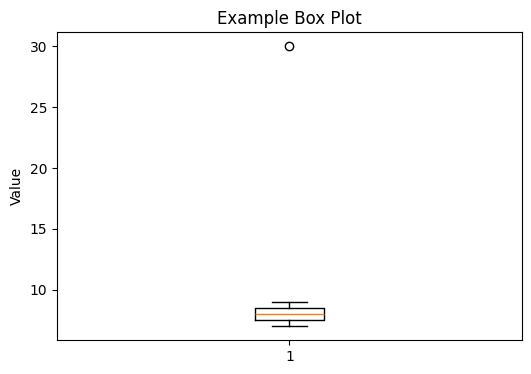

In [4]:
sample_data = [7, 8, 8, 9, 8, 7, 30]

plt.figure(figsize=(6, 4))
plt.boxplot(sample_data)
plt.ylabel("Value")
plt.title("Example Box Plot")
plt.show()

## H — Homogeneity of Variance

The population variances across the groups should be approximately equal.

Conceptually:

$$
\sigma_1^2\approx\sigma_2^2\approx\sigma_3^2
$$

In [5]:
group_a = np.array([10, 11, 12, 13, 14])
group_b = np.array([20, 21, 22, 23, 24])
group_c = np.array([30, 31, 32, 33, 34])

print("Variance Group A:", np.var(group_a, ddof=1))
print("Variance Group B:", np.var(group_b, ddof=1))
print("Variance Group C:", np.var(group_c, ddof=1))

Variance Group A: 2.5
Variance Group B: 2.5
Variance Group C: 2.5


## I — Independent and Random Samples

The observations should be independent and the samples should be
randomly selected.

One observation should not influence another.

# 3. Types of ANOVA

The three types discussed are:

1. One-Way ANOVA
2. Repeated Measures ANOVA
3. Factorial ANOVA

## One-Way ANOVA

One factor + two or more independent levels.

Example:

**Medicine**

Levels:

- 10 mg
- 20 mg
- 30 mg

$$
\boxed{\text{One-Way ANOVA}}
$$

## Repeated Measures ANOVA

One factor + two or more dependent levels.

The same participants are measured repeatedly.

Example:

**Running**

Levels:

- Day 1
- Day 2
- Day 3

$$
\boxed{\text{Repeated Measures ANOVA}}
$$

## Factorial ANOVA

Two or more factors, each with at least two levels.

Example:

**Factor 1:** Running

- Day 1
- Day 2
- Day 3

**Factor 2:** Gender

- Male
- Female

$$
\boxed{\text{Factorial ANOVA}}
$$

## Quick Decision Tree

```text
                    ANOVA
                      │
              How many factors?
                 /           \
               One          2 or more
                │               │
         Are levels?      Factorial ANOVA
          /       \
 Independent     Dependent
     │               │
One-Way ANOVA   Repeated Measures
                    ANOVA
```

# 4. One-Way ANOVA — Medication and Headache

A doctor wants to test a medication that reduces headaches.

There are three dosage groups:

- 15 mg
- 30 mg
- 45 mg

Patients rate their headache from 1 to 10.

We will perform a One-Way ANOVA at:

$$
\alpha=0.05
$$

In [6]:
# Medication dosage groups

group_15mg = np.array([9, 8, 7, 8, 8, 9, 8])

group_30mg = np.array([7, 6, 5, 7, 8, 8, 6])

group_45mg = np.array([4, 3, 2, 3, 4, 3, 2])

print("15 mg:", group_15mg)
print("30 mg:", group_30mg)
print("45 mg:", group_45mg)

15 mg: [9 8 7 8 8 9 8]
30 mg: [7 6 5 7 8 8 6]
45 mg: [4 3 2 3 4 3 2]


In [7]:
# Basic group information

groups = {
    "15 mg": group_15mg,
    "30 mg": group_30mg,
    "45 mg": group_45mg
}

for name, group in groups.items():
    print(
        f"{name}: "
        f"n={len(group)}, "
        f"mean={np.mean(group):.2f}"
    )

15 mg: n=7, mean=8.14
30 mg: n=7, mean=6.71
45 mg: n=7, mean=3.00


C:\Users\Aahish\AppData\Local\Temp\ipykernel_29556\3212679727.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


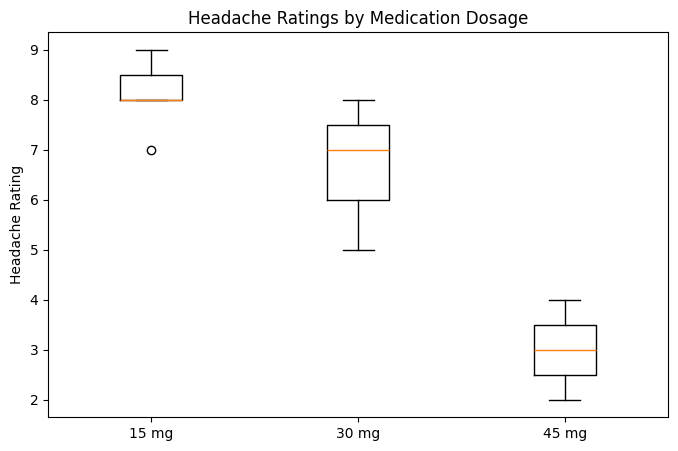

In [8]:
# Visualize the group distributions

plt.figure(figsize=(8, 5))

plt.boxplot(
    [group_15mg, group_30mg, group_45mg],
    labels=["15 mg", "30 mg", "45 mg"]
)

plt.ylabel("Headache Rating")
plt.title("Headache Ratings by Medication Dosage")

plt.show()

# 5. Hypotheses

### Null Hypothesis

$$
H_0:
\mu_{15mg}
=
\mu_{30mg}
=
\mu_{45mg}
$$

### Alternative Hypothesis

$$
H_1:
\text{Not all means are equal}
$$

The alternative hypothesis does **not** mean that every group mean is
different.

It only means that at least one mean differs.

In [9]:
alpha = 0.05
confidence_level = 1 - alpha

print("Significance level:", alpha)
print("Confidence level:", confidence_level)

Significance level: 0.05
Confidence level: 0.95


# 6. Degrees of Freedom

There are:

- 3 groups
- 7 observations per group
- 21 total observations

Let:

$$
a=3
$$

and:

$$
N=21
$$

### Between Groups

$$
df_{Between}=a-1
$$

### Within Groups

$$
df_{Within}=N-a
$$

### Total

$$
df_{Total}=N-1
$$

In [10]:
a = len(groups)
N = sum(len(group) for group in groups.values())

df_between = a - 1
df_within = N - a
df_total = N - 1

print("Number of groups:", a)
print("Total observations:", N)
print("df Between:", df_between)
print("df Within:", df_within)
print("df Total:", df_total)

print(
    "\nCheck:",
    df_between + df_within,
    "=", df_total
)

Number of groups: 3
Total observations: 21
df Between: 2
df Within: 18
df Total: 20

Check: 20 = 20


In [11]:
group_totals = {
    name: group.sum()
    for name, group in groups.items()
}

print(group_totals)

{'15 mg': np.int64(57), '30 mg': np.int64(47), '45 mg': np.int64(21)}


The group totals are:

$$
15mg=57
$$

$$
30mg=47
$$

$$
45mg=21
$$

Grand total:

$$
T=57+47+21=125
$$

# 7. Sum of Squares Between

The formula used in the lecture is:

$$
SS_{Between}
=
\sum
\frac{(\sum A_i)^2}{n}
-
\frac{T^2}{N}
$$

where:

- $A_i$ = observations in each group
- $n$ = observations per group
- $T$ = grand total
- $N$ = total observations

In [12]:
n_per_group = len(group_15mg)
T = sum(group_totals.values())

ss_between = (
    sum(total**2 / n_per_group for total in group_totals.values())
    - (T**2 / N)
)

print("Grand total:", T)
print("SS Between:", ss_between)

Grand total: 125
SS Between: 98.66666666666674


# 8. Sum of Squares Within

The lecture uses:

$$
SS_{Within}
=
\sum Y^2
-
\sum
\frac{(\sum A_i)^2}{n}
$$

In [13]:
# Calculate Sum of Squares Within

sum_y_squared = sum(
    np.sum(group**2)
    for group in groups.values()
)

correction_factor = sum(
    total**2 / n_per_group
    for total in group_totals.values()
)

ss_within = sum_y_squared - correction_factor

print("ΣY²:", sum_y_squared)
print("Correction factor:", correction_factor)
print("SS Within:", ss_within)

ΣY²: 857
Correction factor: 842.7142857142858
SS Within: 14.28571428571422


## Sum of Squares Within

$$
\sum Y^2=857
$$

Therefore:

$$
SS_{Within}
=
857
-
\frac{57^2+47^2+21^2}{7}
$$

$$
\boxed{
SS_{Within}\approx14.29
}
$$

In [14]:
# Calculate Total Sum of Squares

ss_total = ss_between + ss_within

print("SS Between:", ss_between)
print("SS Within:", ss_within)
print("SS Total:", ss_total)

SS Between: 98.66666666666674
SS Within: 14.28571428571422
SS Total: 112.95238095238096


# 8. Total Sum of Squares

The total variation is:

$$
SS_{Total}
=
SS_{Between}
+
SS_{Within}
$$

Using our calculated values:

$$
SS_{Total}
=
98.67+14.29
$$

Therefore:

$$
\boxed{SS_{Total}\approx112.95}
$$

The variance has been partitioned into:

- Between-group variation
- Within-group variation

In [15]:
# Create the ANOVA Sum of Squares table

anova_table = pd.DataFrame({
    "Source": ["Between", "Within", "Total"],
    "SS": [ss_between, ss_within, ss_total],
    "df": [df_between, df_within, df_total]
})

anova_table

,Source,SS,df
0,Between,98.666667,2
1,Within,14.285714,18
2,Total,112.952381,20


# 9. Mean Squares

Mean Square is:

$$
MS=\frac{SS}{df}
$$

Therefore:

$$
MS_{Between}
=
\frac{SS_{Between}}{df_{Between}}
$$

and:

$$
MS_{Within}
=
\frac{SS_{Within}}{df_{Within}}
$$

In [16]:
# Calculate Mean Squares

ms_between = ss_between / df_between
ms_within = ss_within / df_within

print("MS Between:", ms_between)
print("MS Within:", ms_within)

MS Between: 49.33333333333337
MS Within: 0.79365079365079


The calculated Mean Squares are approximately:

$$
MS_{Between}\approx49.33
$$

$$
MS_{Within}\approx0.79
$$

# 10. F-Statistic

The F-statistic compares between-group variation with within-group
variation.

$$
\boxed{
F=
\frac{MS_{Between}}
{MS_{Within}}
}
$$

In [17]:
# Calculate F-statistic

F_calculated = ms_between / ms_within

print("F-statistic:", F_calculated)

F-statistic: 62.16000000000033


The F-statistic is approximately:

$$
\boxed{F\approx62.16}
$$

A larger F-statistic indicates that the variation between the group means
is large relative to the variation within the groups.

# 11. Critical F-Value

The F-distribution is right-skewed.

For this example:

$$
\alpha=0.05
$$

with:

$$
df_1=df_{Between}=2
$$

and:

$$
df_2=df_{Within}=18
$$

the critical F-value is approximately:

$$
\boxed{F_{critical}\approx3.5546}
$$

In [18]:
# Calculate the critical F-value

F_critical = stats.f.ppf(
    1 - alpha,
    df_between,
    df_within
)

print("Critical F-value:", F_critical)

Critical F-value: 3.5545571456617866


# 12. Decision Rule

The decision rule is:

$$
F_{calculated}>F_{critical}
\Rightarrow
\text{Reject }H_0
$$

Otherwise:

$$
F_{calculated}\leq F_{critical}
\Rightarrow
\text{Fail to reject }H_0
$$

In [19]:
# Critical-value decision

if F_calculated > F_critical:
    decision = "Reject H₀"
else:
    decision = "Fail to reject H₀"

print("Calculated F:", F_calculated)
print("Critical F:", F_critical)
print("Decision:", decision)

Calculated F: 62.16000000000033
Critical F: 3.5545571456617866
Decision: Reject H₀


# 13. Final Conclusion

We have:

$$
F_{calculated}\approx62.16
$$

and:

$$
F_{critical}\approx3.5546
$$

Since:

$$
62.16>3.5546
$$

we reject the null hypothesis.

$$
\boxed{\text{Reject }H_0}
$$

### Conclusion

There is a statistically significant difference among the three dosage
conditions.

Therefore:

> **Not all three group means are equal.**

ANOVA tells us that **at least one group mean differs**, but the ANOVA
result alone does not tell us which specific groups are significantly
different from one another.

# 14. One-Way ANOVA Using SciPy

Now we can compare our manual calculation with SciPy's implementation.

SciPy provides:

```python
stats.f_oneway()
```

In [20]:
# Perform One-Way ANOVA using SciPy

F_scipy, p_value = stats.f_oneway(
    group_15mg,
    group_30mg,
    group_45mg
)

print("F-statistic:", F_scipy)
print("p-value:", p_value)

F-statistic: 62.16000000000003
p-value: 8.280548977201281e-09


In [21]:
# Make the decision using the p-value

if p_value < alpha:
    decision = "Reject H₀"
else:
    decision = "Fail to reject H₀"

print("p-value:", p_value)
print("Significance level:", alpha)
print("Decision:", decision)

p-value: 8.280548977201281e-09
Significance level: 0.05
Decision: Reject H₀


# 15. Manual Calculation vs SciPy

Our manual calculation gives:

$$
F\approx62.16
$$

SciPy should produce the same F-statistic.

The p-value is also far below:

$$
\alpha=0.05
$$

Therefore, both approaches lead to the same conclusion:

$$
\boxed{\text{Reject }H_0}
$$

# 15. Manual Calculation vs SciPy

Our manual calculation gives:

$$
F\approx62.16
$$

SciPy should produce the same F-statistic.

The p-value is also far below:

$$
\alpha=0.05
$$

Therefore, both approaches lead to the same conclusion:

$$
\boxed{\text{Reject }H_0}
$$

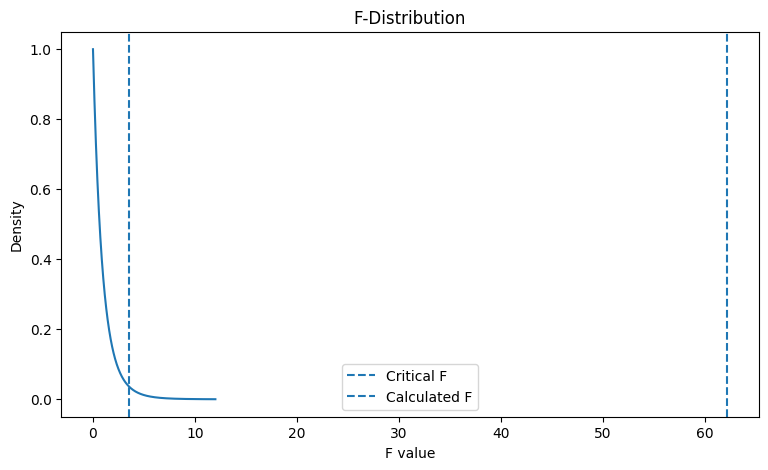

In [22]:
# Visualize the F-distribution

x = np.linspace(0, 12, 500)

y = stats.f.pdf(
    x,
    df_between,
    df_within
)

plt.figure(figsize=(9, 5))

plt.plot(x, y)

plt.axvline(
    F_critical,
    linestyle="--",
    label="Critical F"
)

plt.axvline(
    F_calculated,
    linestyle="--",
    label="Calculated F"
)

plt.xlabel("F value")
plt.ylabel("Density")
plt.title("F-Distribution")
plt.legend()

plt.show()

# 16. Final ANOVA Summary

### Hypotheses

$$
H_0:
\mu_1=\mu_2=\cdots=\mu_k
$$

$$
H_1:
\text{At least one mean is different}
$$

### Degrees of Freedom

$$
df_{Between}=a-1
$$

$$
df_{Within}=N-a
$$

$$
df_{Total}=N-1
$$

### Sum of Squares

$$
SS_{Total}
=
SS_{Between}+SS_{Within}
$$

### Mean Square

$$
MS=\frac{SS}{df}
$$

### F-Statistic

$$
F=
\frac{MS_{Between}}
{MS_{Within}}
$$

### Decision

$$
F_{calculated}>F_{critical}
\Rightarrow
\text{Reject }H_0
$$

### This Example

$$
SS_{Between}\approx98.67
$$

$$
SS_{Within}\approx14.29
$$

$$
SS_{Total}\approx112.95
$$

$$
F\approx62.16
$$

Since:

$$
62.16>3.5546
$$

we reject $H_0$.

### Core Idea

> **ANOVA determines whether the variation between groups is large
> relative to the variation within groups.**

$$
\boxed{
F=
\frac{\text{Between-Group Variation}}
{\text{Within-Group Variation}}
}
$$